In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, MixtureSameFamily, Normal

torch.manual_seed(42);

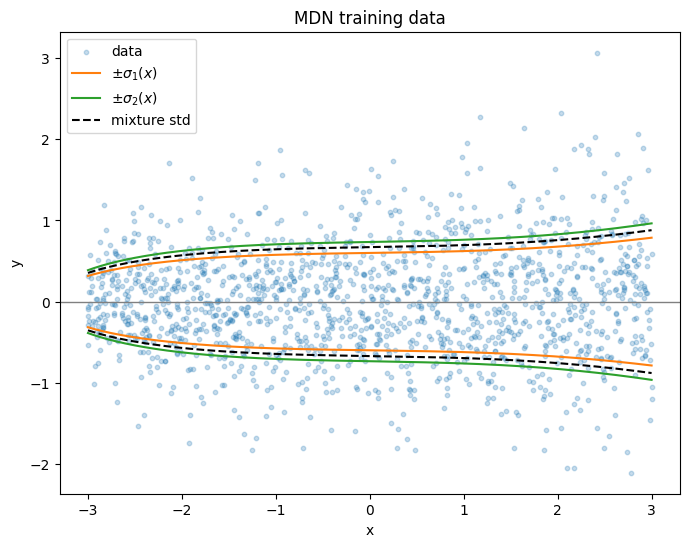

In [2]:
# prepare dataset
# y|x is a mixture of two zero-mean Gaussians.
# Only the spread changes with x, so predicting only the mean is not enough.
x_base = torch.linspace(-3.0, 3.0, 250).unsqueeze(1)
x = x_base.repeat_interleave(6, dim=0)
x = x + 0.05 * torch.randn_like(x)
x = torch.clamp(x, -3.0, 3.0)
n_samples = x.shape[0]

def component_variances(x_value):
    # Make two positive, cubic-like variance curves.
    z = x_value.squeeze(-1) / 3.0
    cubic = z**3 + 0.30 * z

    var1 = torch.clamp(0.08 + 0.20 * (cubic + 1.4), min=0.03)
    var2 = torch.clamp(0.18 + 0.30 * (cubic + 1.2), min=0.05)
    return var1.unsqueeze(-1), var2.unsqueeze(-1)

var1, var2 = component_variances(x)
sigma1 = torch.sqrt(var1)
sigma2 = torch.sqrt(var2)

component_id = torch.bernoulli(torch.full_like(x, 0.5))
y_from_first = torch.randn_like(x) * sigma1
y_from_second = torch.randn_like(x) * sigma2
y = torch.where(component_id == 0, y_from_first, y_from_second)

x_train = x.float()
y_train = y.float()

x_plot = torch.linspace(-3.0, 3.0, 400).unsqueeze(1)
var1_plot, var2_plot = component_variances(x_plot)
sigma1_plot = torch.sqrt(var1_plot)
sigma2_plot = torch.sqrt(var2_plot)
mixture_std_plot = torch.sqrt(0.5 * (var1_plot + var2_plot))

plt.figure(figsize=(8, 6))
plt.scatter(x_train.squeeze(1).numpy(), y_train.squeeze(1).numpy(), s=10, alpha=0.25, label='data')
plt.plot(x_plot.squeeze(1).numpy(), sigma1_plot.squeeze(1).numpy(), color='tab:orange', label=r'$\pm \sigma_1(x)$')
plt.plot(x_plot.squeeze(1).numpy(), -sigma1_plot.squeeze(1).numpy(), color='tab:orange')
plt.plot(x_plot.squeeze(1).numpy(), sigma2_plot.squeeze(1).numpy(), color='tab:green', label=r'$\pm \sigma_2(x)$')
plt.plot(x_plot.squeeze(1).numpy(), -sigma2_plot.squeeze(1).numpy(), color='tab:green')
plt.plot(x_plot.squeeze(1).numpy(), mixture_std_plot.squeeze(1).numpy(), color='black', linestyle='--', label='mixture std')
plt.plot(x_plot.squeeze(1).numpy(), -mixture_std_plot.squeeze(1).numpy(), color='black', linestyle='--')
plt.axhline(0.0, color='gray', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('MDN training data')
plt.legend()
plt.show()

In [ ]:
# define model
class MDN(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=64, out_dim=1, n_components=2):
        super().__init__()
        self.out_dim = out_dim
        self.n_components = n_components

        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        self.pi_layer = nn.Linear(hidden_dim, n_components)
        self.mu_layer = nn.Linear(hidden_dim, n_components * out_dim)
        self.log_sigma_layer = nn.Linear(hidden_dim, n_components * out_dim)

    def forward(self, x):
        h = self.backbone(x)
        pi_logits = self.pi_layer(h)
        mu = self.mu_layer(h).view(-1, self.n_components, self.out_dim)
        log_sigma = self.log_sigma_layer(h).view(-1, self.n_components, self.out_dim)

        sigma = F.softplus(log_sigma) + 1e-4
        return pi_logits, mu, sigma

    def distribution(self, x):
        pi_logits, mu, sigma = self(x)

        mix = Categorical(logits=pi_logits)
        comp = Normal(loc=mu, scale=sigma)
        comp = torch.distributions.Independent(comp, 1)
        return MixtureSameFamily(mix, comp)

    def nll(self, x, y):
        return -self.distribution(x).log_prob(y).mean()

    @torch.no_grad()
    def component_parameters(self, x):
        pi_logits, mu, sigma = self(x)
        pi = torch.softmax(pi_logits, dim=-1)
        return pi, mu, sigma

    @torch.no_grad()
    def predict_mean(self, x):
        return self.distribution(x).mean

    @torch.no_grad()
    def predict_variance(self, x):
        pi, mu, sigma = self.component_parameters(x)
        second_moment = torch.sum(pi.unsqueeze(-1) * (sigma**2 + mu**2), dim=1)
        mean = torch.sum(pi.unsqueeze(-1) * mu, dim=1)
        return torch.clamp(second_moment - mean**2, min=1e-8)
    
    @torch.no_grad()
    def predict_kurtosis(self, x):
        pi, mu, sigma = self.component_parameters(x)
        fourth_moment = torch.sum(pi.unsqueeze(-1) * (3 * sigma**4 + 6 * sigma**2 * mu**2 + mu**4), dim=1)
        mean = torch.sum(pi.unsqueeze(-1) * mu, dim=1)
        variance = self.predict_variance(x)
        return torch.clamp(fourth_moment - 4 * mean * variance - 6 * mean**2 * variance - mean**4, min=1e-8)

    @torch.no_grad()
    def sample(self, x, n_samples=1):
        return self.distribution(x).sample((n_samples,))

In [4]:
# define training loop
def train(model, x_train, y_train, num_epochs=2000, learning_rate=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        loss = model.nll(x_train, y_train)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (epoch + 1) % max(1, num_epochs // 10) == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], NLL: {loss.item():.4f}')

    return loss_history

Epoch [200/2000], NLL: 0.9960
Epoch [400/2000], NLL: 0.9930
Epoch [600/2000], NLL: 0.9924
Epoch [800/2000], NLL: 0.9920
Epoch [1000/2000], NLL: 0.9918
Epoch [1200/2000], NLL: 0.9916
Epoch [1400/2000], NLL: 0.9913
Epoch [1600/2000], NLL: 0.9909
Epoch [1800/2000], NLL: 0.9898
Epoch [2000/2000], NLL: 0.9877


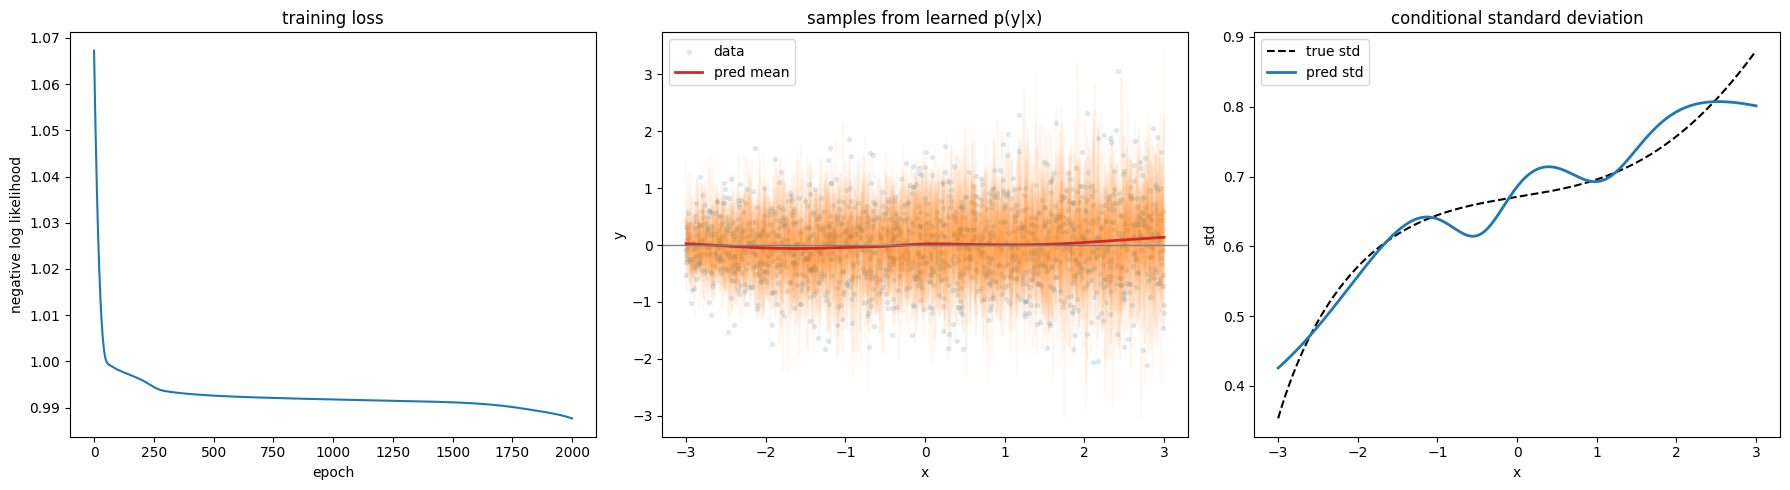

In [6]:
# training start
model = MDN(in_dim=1, hidden_dim=8, out_dim=1, n_components=2)
loss_history = train(model, x_train, y_train, num_epochs=2000, learning_rate=1e-3)

model.eval()
x_test = torch.linspace(-3.0, 3.0, 400).unsqueeze(1)
true_var1, true_var2 = component_variances(x_test)
true_std = torch.sqrt(0.5 * (true_var1 + true_var2))

with torch.no_grad():
    predicted_mean = model.predict_mean(x_test)
    predicted_std = torch.sqrt(model.predict_variance(x_test))
    predicted_samples = model.sample(x_test, n_samples=25)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(loss_history)
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('negative log likelihood')
axes[0].set_title('training loss')

x_train_np = x_train.squeeze(1).numpy()
y_train_np = y_train.squeeze(1).numpy()
x_test_np = x_test.squeeze(1).numpy()
predicted_mean_np = predicted_mean.squeeze(1).numpy()

axes[1].scatter(x_train_np, y_train_np, s=8, alpha=0.12, label='data')
for sample_index in range(predicted_samples.shape[0]):
    axes[1].plot(
        x_test_np,
        predicted_samples[sample_index].squeeze(1).numpy(),
        color='tab:orange',
        alpha=0.06,
    )
axes[1].plot(x_test_np, predicted_mean_np, color='tab:red', linewidth=2, label='pred mean')
axes[1].axhline(0.0, color='gray', linewidth=1)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('samples from learned p(y|x)')
axes[1].legend()

axes[2].plot(x_test_np, true_std.squeeze(1).numpy(), color='black', linestyle='--', label='true std')
axes[2].plot(x_test_np, predicted_std.squeeze(1).numpy(), color='tab:blue', linewidth=2, label='pred std')
axes[2].set_xlabel('x')
axes[2].set_ylabel('std')
axes[2].set_title('conditional standard deviation')
axes[2].legend()

plt.tight_layout()
plt.show()